In [2]:
import os
import pandas as pd
import numpy as np
import random
from scipy.stats import truncnorm

In [2]:
this_dir = os.getcwd()
work_dir = os.path.dirname(this_dir)
write_dir = "/mnt/storage/franklhtan/projects/LearnCsld2025/data_VN/"    # NOTE: VW=vowel, this is for extended study, we also normalized it using Global Min-Max
# NOTE: this is repaired version of vowel: F2 was not properly generated; although it may not affect the results currently, it will largely interupt later condition organizations. 

In [1]:
manipulant_means = [-1, -1, -1, 0, 0]   # f1 & vowel_duration, f2, cog, fri_dur
manipulant_stds = [50, 25, 150, 0, 0]   # f1 & vowel_duration, f2, cog, fri_dur: NOTE: we make sure the variance is the same across the two dimensions relative to range.
concurrent_means = [0, 0, 0, 8000, 200]   # consonant: f1 & vowel_duration, f2, cog, fri_dur
concurrent_stds = [0, 0, 0, 500, 25]

all_means = concurrent_means + manipulant_means + concurrent_means # CVC
all_stds = concurrent_stds + manipulant_stds + concurrent_stds

any_mins = [200, 0, 500, 2000, 0]   # F1, dur, F2, COG, FRI_dur
any_maxs = [1200, 500, 3500, 12000, 500]

print(all_means)
print(all_stds)
print(any_mins)
print(any_maxs)

[0, 0, 0, 8000, 200, -1, -1, -1, 0, 0, 0, 0, 0, 8000, 200]
[0, 0, 0, 500, 25, 50, 25, 150, 0, 0, 0, 0, 0, 500, 25]
[200, 0, 500, 2000, 0]
[1200, 500, 3500, 12000, 500]


In [4]:
def generate_data_for_one_dim(mean, std, a=-2, b=2, sample_size=8000): 
    # NOTE: it turns out that truncnorm can take std = 0, then we can just fill in everything directly. 
    dist = truncnorm(a, b, loc = mean, scale = std)
    return dist.rvs(size = sample_size)

## Equal

In [5]:
condition = "test_equal"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)

manipulant_list = ['e', 'o', 'i', 'u', 
                   'iL', 'uL', 'ihS', 'uhS', 
                   'iS', 'uS', 'ihL', 'uhL']    # the maniputated targets: S = short, L = long. 
manipulant_f1 = [500, 500, 300, 300, 
                 250, 250, 350, 350, 
                 250, 250, 350, 350]
manipulant_dur = [200, 200, 200, 200, 
                  200, 200, 150, 150, 
                  150, 150, 200, 200]
manipulant_f2 = [1500, 900, 1500, 900, 
                 1500, 900, 1500, 900, 
                 1500, 900, 1500, 900]
train_refs = [1, 2, 3, 4, 
              5, 6, 7, 8, 
              9, 10, 11, 12]

# no. of tokens for each word
sample_size = 2000

metadata = []

for index in range (12):
    vowel = manipulant_list[index]
    f1 = manipulant_f1[index]
    dur = manipulant_dur[index]
    f2 = manipulant_f2[index]
    train_ref = train_refs[index]

    consonant = 's' # use one consonant as the context first.
    word = consonant + vowel +consonant # CVC structure

    target_means = np.array([f1, dur, f2])
    manipulant_means_actual = np.concatenate((target_means, np.array(manipulant_means[3:])))  # cog, fri_dur are replaced by the specific values for each consonant, but the rest are the same across all consonants.
    manipulant_stds_actual = np.array(manipulant_stds)

    manipulants = np.zeros((sample_size, len(manipulant_means_actual)))
    for i in range(len(manipulant_means_actual)): # NOTE: this only takes care of the first three dimensions
        manipulants[:, i] = generate_data_for_one_dim(manipulant_means_actual[i], manipulant_stds_actual[i], sample_size=sample_size)

    concurrent_means_actual = np.array(concurrent_means)
    concurrent_stds_actual = np.array(concurrent_stds)

    concurrents = np.zeros((sample_size, len(concurrent_means_actual)))
    for i in range(len(concurrent_means_actual)):
        concurrents[:, i] = generate_data_for_one_dim(concurrent_means_actual[i], concurrent_stds_actual[i], sample_size=sample_size)

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    manipulants = manipulants[:, np.newaxis, :]
    concurrents = concurrents[:, np.newaxis, :]

    all_tokens = np.concatenate([concurrents, manipulants, concurrents], axis=1)
    all_mins = np.array([any_mins, any_mins, any_mins])
    all_maxs = np.array([any_maxs, any_maxs, any_maxs])

    norm_all_tokens = (all_tokens - all_mins) / (all_maxs - all_mins)

    for i in range(sample_size):
        uid = word + f'_{i+1:04d}'
        filename = f'{uid}.npy'
        save_path = os.path.join(subdata_dir, filename)
        token = norm_all_tokens[i]
        np.save(save_path, token)

        # save_path_rel = os.path.relpath(save_path, start=work_dir)
        save_path_rel = os.path.join(write_dir, f'data_{condition}', word, filename)
        metadata.append({
            'uid': uid,
            'path': save_path_rel,
            'f1': token[1][0],
            'vowel_dur': token[1][1],
            'f2': token[1][2],
            'word': word,
            'vowel': vowel,
            'consonant': consonant,
            'train': train_ref
        })

csv_name = f'metadata_{condition}.csv'
csv_path = os.path.join(data_dir, csv_name)
metaframe = pd.DataFrame(metadata)
metaframe.to_csv(csv_path, index=False)


In [6]:
condition = "train_equal"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)

manipulant_list = ['e', 'o', 'i', 'u', 
                   'iL', 'uL', 'ihS', 'uhS', 
                   'iS', 'uS', 'ihL', 'uhL']    # the maniputated targets: S = short, L = long. 
manipulant_f1 = [500, 500, 300, 300, 
                 250, 250, 350, 350, 
                 250, 250, 350, 350]
manipulant_dur = [200, 200, 200, 200, 
                  200, 200, 150, 150, 
                  150, 150, 200, 200]
manipulant_f2 = [1500, 900, 1500, 900, 
                 1500, 900, 1500, 900, 
                 1500, 900, 1500, 900]
train_refs = [1, 2, 3, 4, 
              5, 6, 7, 8, 
              9, 10, 11, 12]

# no. of tokens for each word
sample_size = 8000

metadata = []

for index in range (12):
    vowel = manipulant_list[index]
    f1 = manipulant_f1[index]
    dur = manipulant_dur[index]
    f2 = manipulant_f2[index]
    train_ref = train_refs[index]

    consonant = 's' # use one consonant as the context first.
    word = consonant + vowel +consonant # CVC structure

    target_means = np.array([f1, dur, f2])
    manipulant_means_actual = np.concatenate((target_means, np.array(manipulant_means[3:])))  # cog, fri_dur are replaced by the specific values for each consonant, but the rest are the same across all consonants.
    manipulant_stds_actual = np.array(manipulant_stds)

    manipulants = np.zeros((sample_size, len(manipulant_means_actual)))
    for i in range(len(manipulant_means_actual)): # NOTE: this only takes care of the first three dimensions
        manipulants[:, i] = generate_data_for_one_dim(manipulant_means_actual[i], manipulant_stds_actual[i], sample_size=sample_size)

    concurrent_means_actual = np.array(concurrent_means)
    concurrent_stds_actual = np.array(concurrent_stds)

    concurrents = np.zeros((sample_size, len(concurrent_means_actual)))
    for i in range(len(concurrent_means_actual)):
        concurrents[:, i] = generate_data_for_one_dim(concurrent_means_actual[i], concurrent_stds_actual[i], sample_size=sample_size)

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    manipulants = manipulants[:, np.newaxis, :]
    concurrents = concurrents[:, np.newaxis, :]

    all_tokens = np.concatenate([concurrents, manipulants, concurrents], axis=1)
    all_mins = np.array([any_mins, any_mins, any_mins])
    all_maxs = np.array([any_maxs, any_maxs, any_maxs])

    norm_all_tokens = (all_tokens - all_mins) / (all_maxs - all_mins)

    for i in range(sample_size):
        uid = word + f'_{i+1:04d}'
        filename = f'{uid}.npy'
        save_path = os.path.join(subdata_dir, filename)
        token = norm_all_tokens[i]
        np.save(save_path, token)

        # save_path_rel = os.path.relpath(save_path, start=work_dir)
        save_path_rel = os.path.join(write_dir, f'data_{condition}', word, filename)
        metadata.append({
            'uid': uid,
            'path': save_path_rel,
            'f1': token[1][0],
            'vowel_dur': token[1][1],
            'f2': token[1][2],
            'word': word,
            'vowel': vowel,
            'consonant': consonant,
            'train': train_ref
        })

csv_name = f'metadata_{condition}.csv'
csv_path = os.path.join(data_dir, csv_name)
metaframe = pd.DataFrame(metadata)
metaframe.to_csv(csv_path, index=False)


### Visualize

In [7]:
condition = "train_equal"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)

manipulant_list = ['e', 'o', 'i', 'u', 
                   'iL', 'uL', 'ihS', 'uhS', 
                   'iS', 'uS', 'ihL', 'uhL']    # the maniputated targets: S = short, L = long. 
manipulant_f1 = [500, 500, 300, 300, 
                 250, 250, 350, 350, 
                 250, 250, 350, 350]
manipulant_dur = [200, 200, 200, 200, 
                  200, 200, 150, 150, 
                  150, 150, 200, 200]
manipulant_f2 = [1500, 900, 1500, 900, 
                 1500, 900, 1500, 900, 
                 1500, 900, 1500, 900]
train_refs = [1, 2, 3, 4, 
              5, 6, 7, 8, 
              9, 10, 11, 12]

# no. of tokens for each word
sample_size = 2000

token_dict = {}

for index in range (12):
    vowel = manipulant_list[index]
    f1 = manipulant_f1[index]
    dur = manipulant_dur[index]
    f2 = manipulant_f2[index]
    train_ref = train_refs[index]

    consonant = 's' # use one consonant as the context first.
    word = consonant + vowel +consonant # CVC structure

    target_means = np.array([f1, dur, f2])
    manipulant_means_actual = np.concatenate((target_means, np.array(manipulant_means[3:])))  # cog, fri_dur are replaced by the specific values for each consonant, but the rest are the same across all consonants.
    manipulant_stds_actual = np.array(manipulant_stds)

    manipulants = np.zeros((sample_size, len(manipulant_means_actual)))
    for i in range(len(manipulant_means_actual)): # NOTE: this only takes care of the first three dimensions
        manipulants[:, i] = generate_data_for_one_dim(manipulant_means_actual[i], manipulant_stds_actual[i], sample_size=sample_size)

    concurrent_means_actual = np.array(concurrent_means)
    concurrent_stds_actual = np.array(concurrent_stds)

    concurrents = np.zeros((sample_size, len(concurrent_means_actual)))
    for i in range(len(concurrent_means_actual)):
        concurrents[:, i] = generate_data_for_one_dim(concurrent_means_actual[i], concurrent_stds_actual[i], sample_size=sample_size)

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    manipulants = manipulants[:, np.newaxis, :]
    concurrents = concurrents[:, np.newaxis, :]

    all_tokens = np.concatenate([concurrents, manipulants, concurrents], axis=1)
    all_mins = np.array([any_mins, any_mins, any_mins])
    all_maxs = np.array([any_maxs, any_maxs, any_maxs])

    norm_all_tokens = (all_tokens - all_mins) / (all_maxs - all_mins)

    token_dict[word] = norm_all_tokens


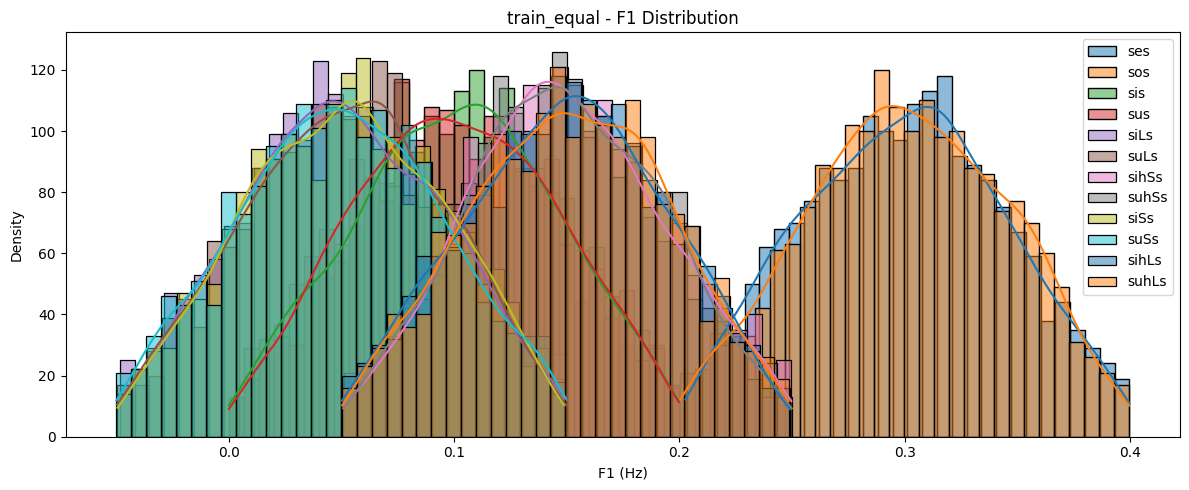

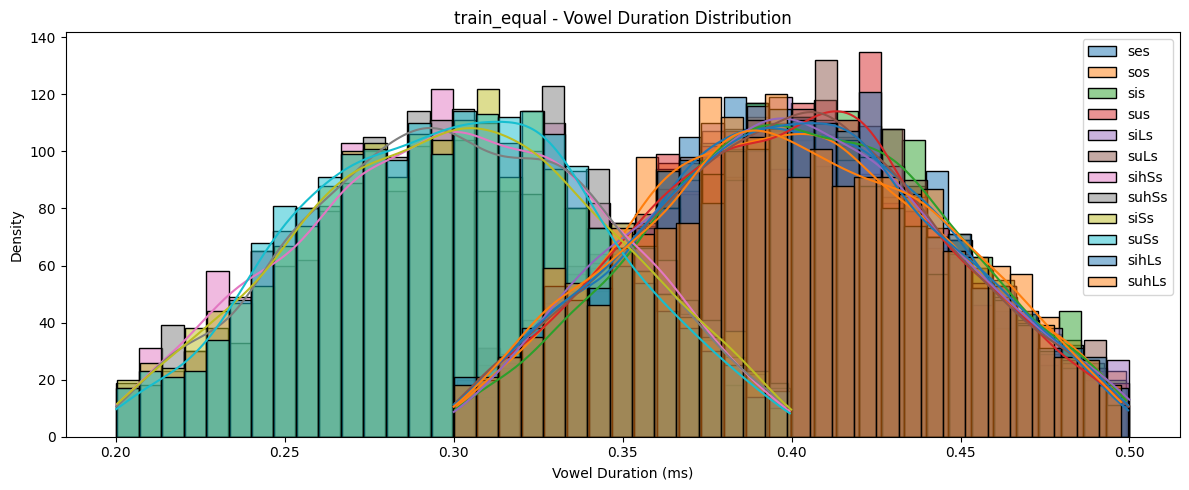

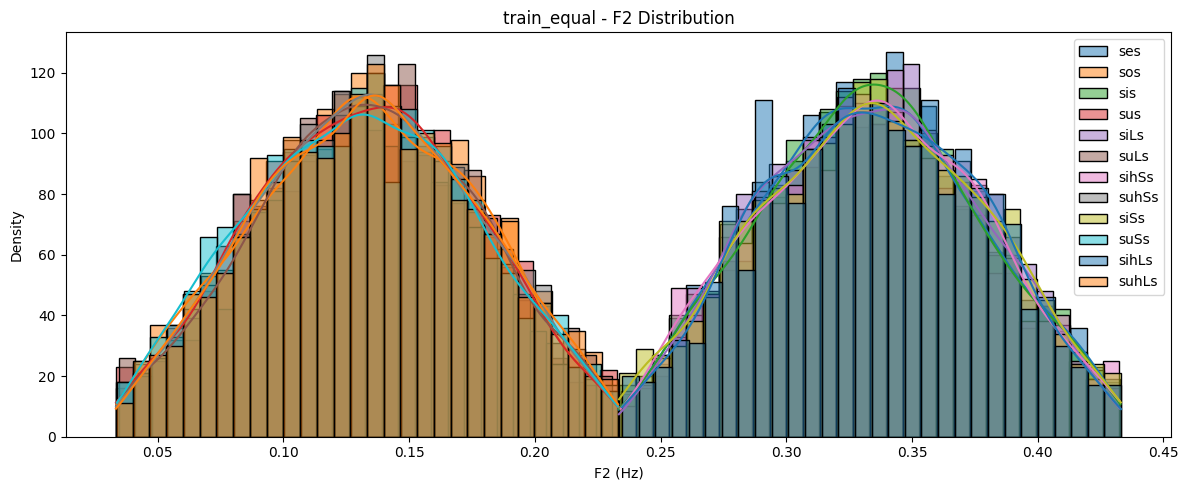

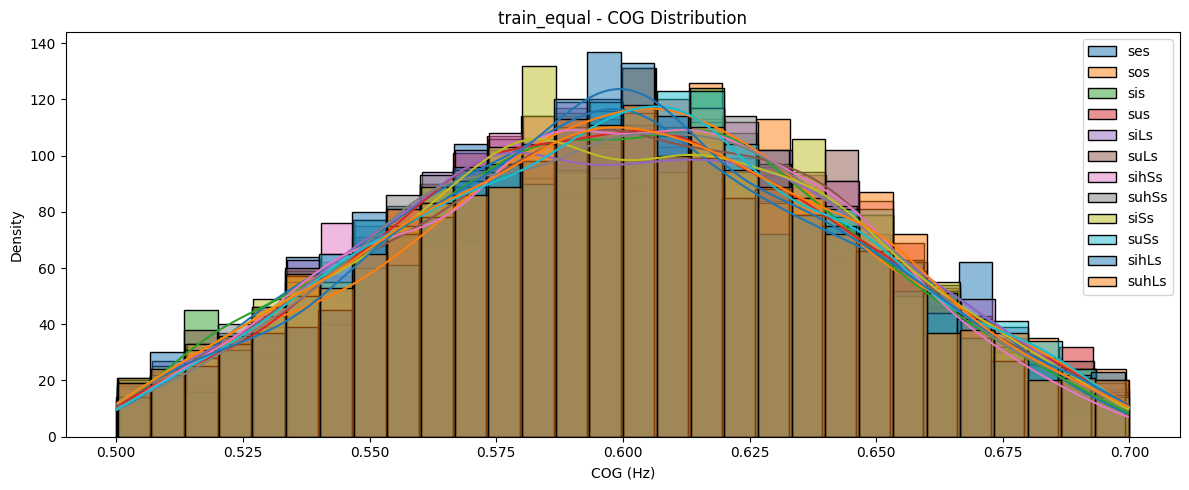

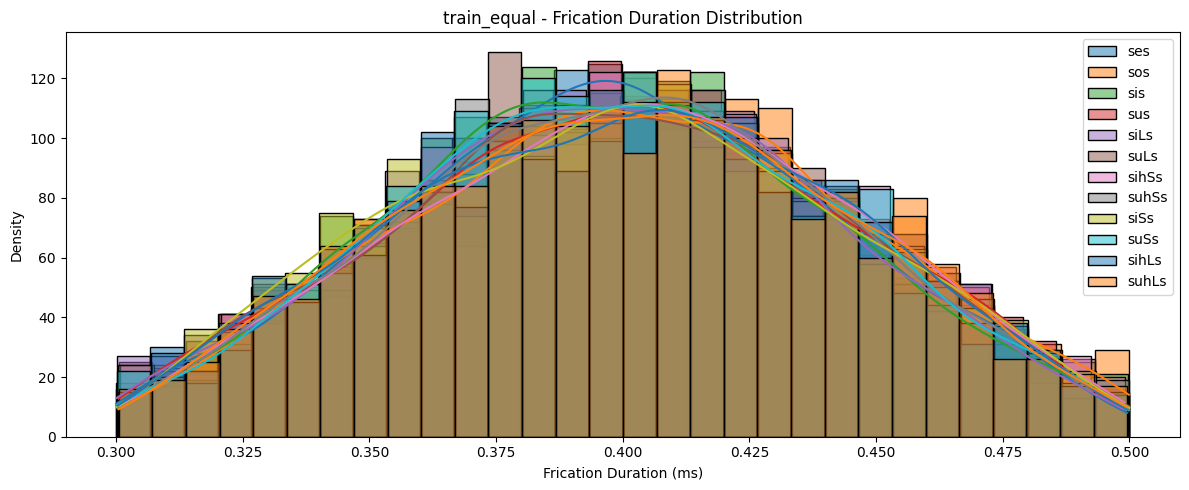

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
# plot the distribution of cog and fri_dur for all four words (words together, plot separate by dimension like cog or fri_dur)
plt.figure(figsize=(12, 5))
for word in token_dict:
    # bar plot and kde plot together
    sns.histplot(token_dict[word][:, 1, 0], bins=30, kde=True, label=word)  # cog is the first dimension of the consonant part
    # sns.kdeplot(token_dict[word][:, 1, 0], label=word)  # cog is the first dimension of the consonant part
plt.title(f'{condition} - F1 Distribution')
plt.xlabel('F1 (Hz)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for word in token_dict: 
    sns.histplot(token_dict[word][:, 1, 1], bins=30, kde=True, label=word)  # fri_dur is the second dimension of the consonant part
    # sns.kdeplot(token_dict[word][:, 1, 1], label=word)  # fri_dur is the second dimension of the consonant part
plt.title(f'{condition} - Vowel Duration Distribution')
plt.xlabel('Vowel Duration (ms)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for word in token_dict:
    # bar plot and kde plot together
    sns.histplot(token_dict[word][:, 1, 2], bins=30, kde=True, label=word)  # cog is the first dimension of the consonant part
    # sns.kdeplot(token_dict[word][:, 1, 2], label=word)  # cog is the first dimension of the consonant part
plt.title(f'{condition} - F2 Distribution')
plt.xlabel('F2 (Hz)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for word in token_dict: 
    sns.histplot(token_dict[word][:, 0, 3], bins=30, kde=True, label=word)  # fri_dur is the second dimension of the consonant part
    # sns.kdeplot(token_dict[word][:, 1, 3], label=word)  # fri_dur is the second dimension of the consonant part
plt.title(f'{condition} - COG Distribution')
plt.xlabel('COG (Hz)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for word in token_dict: 
    sns.histplot(token_dict[word][:, 0, 4], bins=30, kde=True, label=word)  # fri_dur is the second dimension of the consonant part
    # sns.kdeplot(token_dict[word][:, 2, 4], label=word)  # fri_dur is the second dimension of the consonant part
plt.title(f'{condition} - Frication Duration Distribution')
plt.xlabel('Frication Duration (ms)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## Unequal

In [9]:
condition = "test_unequal"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)
dur_long = 250
dur_short = 100

manipulant_list = ['e', 'o', 'i', 'u', 'ih', 'uh', 'iS', 'uS', 'ihL', 'uhL']    # the maniputated targets: S = short, L = long. 
manipulant_f1 = [500, 500, 300, 300, 400, 400, 300, 300, 400, 400]
manipulant_dur = [dur_long, dur_long, dur_long, dur_long, dur_short, dur_short, dur_short, dur_short, dur_long, dur_long]
manipulant_f2 = [1500, 900, 1500, 900, 1500, 900, 1500, 900, 1500, 900]
train_refs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# no. of tokens for each word
sample_size = 8000

metadata = []

for index in range (10):
    vowel = manipulant_list[index]
    f1 = manipulant_f1[index]
    dur = manipulant_dur[index]
    f2 = manipulant_f2[index]
    train_ref = train_refs[index]

    consonant = 's' # use one consonant as the context first.
    word = consonant + vowel +consonant # CVC structure

    target_means = np.array([f1, dur, f2])
    manipulant_means_actual = np.concatenate((target_means, np.array(manipulant_means[3:])))  # cog, fri_dur are replaced by the specific values for each consonant, but the rest are the same across all consonants.
    manipulant_stds_actual = np.array(manipulant_stds)

    manipulants = np.zeros((sample_size, len(manipulant_means_actual)))
    for i in range(len(manipulant_means_actual)): # NOTE: this only takes care of the first three dimensions
        manipulants[:, i] = generate_data_for_one_dim(manipulant_means_actual[i], manipulant_stds_actual[i], sample_size=sample_size)

    concurrent_means_actual = np.array(concurrent_means)
    concurrent_stds_actual = np.array(concurrent_stds)

    concurrents = np.zeros((sample_size, len(concurrent_means_actual)))
    for i in range(len(concurrent_means_actual)):
        concurrents[:, i] = generate_data_for_one_dim(concurrent_means_actual[i], concurrent_stds_actual[i], sample_size=sample_size)

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    manipulants = manipulants[:, np.newaxis, :]
    concurrents = concurrents[:, np.newaxis, :]

    all_tokens = np.concatenate([concurrents, manipulants, concurrents], axis=1)
    all_mins = np.array([any_mins, any_mins, any_mins])
    all_maxs = np.array([any_maxs, any_maxs, any_maxs])

    norm_all_tokens = (all_tokens - all_mins) / (all_maxs - all_mins)

    for i in range(sample_size):
        uid = word + f'_{i+1:04d}'
        filename = f'{uid}.npy'
        save_path = os.path.join(subdata_dir, filename)
        token = norm_all_tokens[i]
        np.save(save_path, token)

        # save_path_rel = os.path.relpath(save_path, start=work_dir)
        save_path_rel = os.path.join(write_dir, f'data_{condition}', word, filename)
        metadata.append({
            'uid': uid,
            'path': save_path_rel,
            'f1': token[1][0],
            'vowel_dur': token[1][1],
            'f2': token[1][2],
            'word': word,
            'vowel': vowel,
            'consonant': consonant,
            'train': train_ref
        })

csv_name = f'metadata_{condition}.csv'
csv_path = os.path.join(data_dir, csv_name)
metaframe = pd.DataFrame(metadata)
metaframe.to_csv(csv_path, index=False)


In [10]:
condition = "train_unequal"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)

dur_long = 250
dur_short = 100

manipulant_list = ['e', 'o', 'i', 'u', 'ih', 'uh', 'iS', 'uS', 'ihL', 'uhL']    # the maniputated targets: S = short, L = long. 
manipulant_f1 = [500, 500, 300, 300, 400, 400, 300, 300, 400, 400]
manipulant_dur = [dur_long, dur_long, dur_long, dur_long, dur_short, dur_short, dur_short, dur_short, dur_long, dur_long]
manipulant_f2 = [1500, 900, 1500, 900, 1500, 900, 1500, 900, 1500, 900]
train_refs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# no. of tokens for each word
sample_size = 8000

metadata = []

for index in range (10):
    vowel = manipulant_list[index]
    f1 = manipulant_f1[index]
    dur = manipulant_dur[index]
    f2 = manipulant_f2[index]
    train_ref = train_refs[index]

    consonant = 's' # use one consonant as the context first.
    word = consonant + vowel +consonant # CVC structure

    target_means = np.array([f1, dur, f2])
    manipulant_means_actual = np.concatenate((target_means, np.array(manipulant_means[3:])))  # cog, fri_dur are replaced by the specific values for each consonant, but the rest are the same across all consonants.
    manipulant_stds_actual = np.array(manipulant_stds)

    manipulants = np.zeros((sample_size, len(manipulant_means_actual)))
    for i in range(len(manipulant_means_actual)): # NOTE: this only takes care of the first three dimensions
        manipulants[:, i] = generate_data_for_one_dim(manipulant_means_actual[i], manipulant_stds_actual[i], sample_size=sample_size)

    concurrent_means_actual = np.array(concurrent_means)
    concurrent_stds_actual = np.array(concurrent_stds)

    concurrents = np.zeros((sample_size, len(concurrent_means_actual)))
    for i in range(len(concurrent_means_actual)):
        concurrents[:, i] = generate_data_for_one_dim(concurrent_means_actual[i], concurrent_stds_actual[i], sample_size=sample_size)

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    manipulants = manipulants[:, np.newaxis, :]
    concurrents = concurrents[:, np.newaxis, :]

    all_tokens = np.concatenate([concurrents, manipulants, concurrents], axis=1)
    all_mins = np.array([any_mins, any_mins, any_mins])
    all_maxs = np.array([any_maxs, any_maxs, any_maxs])

    norm_all_tokens = (all_tokens - all_mins) / (all_maxs - all_mins)

    for i in range(sample_size):
        uid = word + f'_{i+1:04d}'
        filename = f'{uid}.npy'
        save_path = os.path.join(subdata_dir, filename)
        token = norm_all_tokens[i]
        np.save(save_path, token)

        # save_path_rel = os.path.relpath(save_path, start=work_dir)
        save_path_rel = os.path.join(write_dir, f'data_{condition}', word, filename)
        metadata.append({
            'uid': uid,
            'path': save_path_rel,
            'f1': token[1][0],
            'vowel_dur': token[1][1],
            'f2': token[1][2],
            'word': word,
            'vowel': vowel,
            'consonant': consonant,
            'train': train_ref
        })

csv_name = f'metadata_{condition}.csv'
csv_path = os.path.join(data_dir, csv_name)
metaframe = pd.DataFrame(metadata)
metaframe.to_csv(csv_path, index=False)


### Visualize

In [11]:
condition = "train_equal"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)

dur_long = 250
dur_short = 100

manipulant_list = ['e', 'o', 'i', 'u', 'ih', 'uh', 'iS', 'uS', 'ihL', 'uhL']    # the maniputated targets: S = short, L = long. 
manipulant_f1 = [500, 500, 300, 300, 400, 400, 300, 300, 400, 400]
manipulant_dur = [dur_long, dur_long, dur_long, dur_long, dur_short, dur_short, dur_short, dur_short, dur_long, dur_long]
manipulant_f2 = [1500, 900, 1500, 900, 1500, 900, 1500, 900, 1500, 900]
train_refs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# no. of tokens for each word
sample_size = 8000

token_dict = {}

for index in range (10):
    vowel = manipulant_list[index]
    f1 = manipulant_f1[index]
    dur = manipulant_dur[index]
    f2 = manipulant_f2[index]
    train_ref = train_refs[index]

    consonant = 's' # use one consonant as the context first.
    word = consonant + vowel +consonant # CVC structure

    target_means = np.array([f1, dur, f2])
    manipulant_means_actual = np.concatenate((target_means, np.array(manipulant_means[3:])))  # cog, fri_dur are replaced by the specific values for each consonant, but the rest are the same across all consonants.
    manipulant_stds_actual = np.array(manipulant_stds)

    manipulants = np.zeros((sample_size, len(manipulant_means_actual)))
    for i in range(len(manipulant_means_actual)): # NOTE: this only takes care of the first three dimensions
        manipulants[:, i] = generate_data_for_one_dim(manipulant_means_actual[i], manipulant_stds_actual[i], sample_size=sample_size)

    concurrent_means_actual = np.array(concurrent_means)
    concurrent_stds_actual = np.array(concurrent_stds)

    concurrents = np.zeros((sample_size, len(concurrent_means_actual)))
    for i in range(len(concurrent_means_actual)):
        concurrents[:, i] = generate_data_for_one_dim(concurrent_means_actual[i], concurrent_stds_actual[i], sample_size=sample_size)

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    manipulants = manipulants[:, np.newaxis, :]
    concurrents = concurrents[:, np.newaxis, :]

    all_tokens = np.concatenate([concurrents, manipulants, concurrents], axis=1)
    all_mins = np.array([any_mins, any_mins, any_mins])
    all_maxs = np.array([any_maxs, any_maxs, any_maxs])

    norm_all_tokens = (all_tokens - all_mins) / (all_maxs - all_mins)

    token_dict[word] = norm_all_tokens


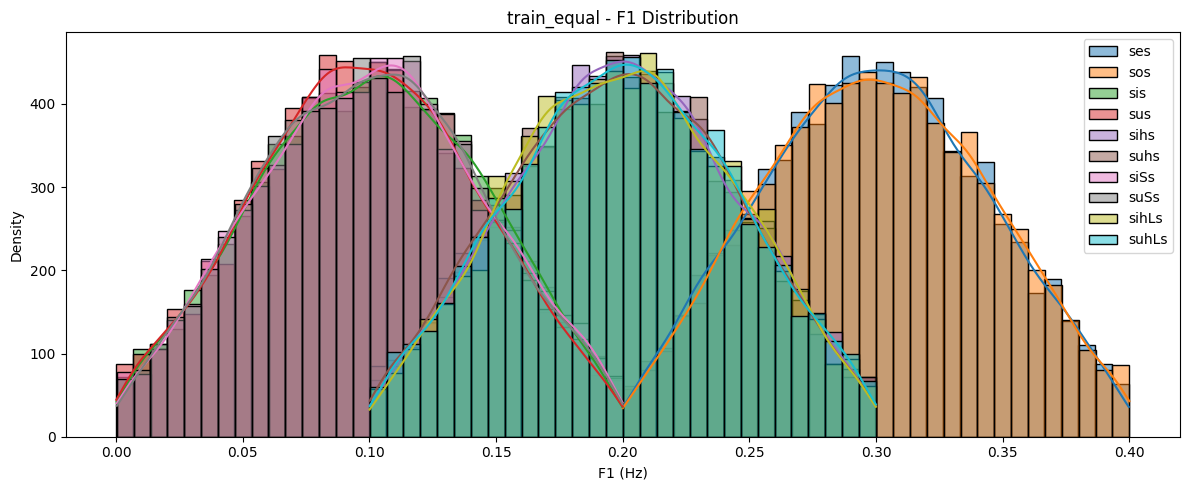

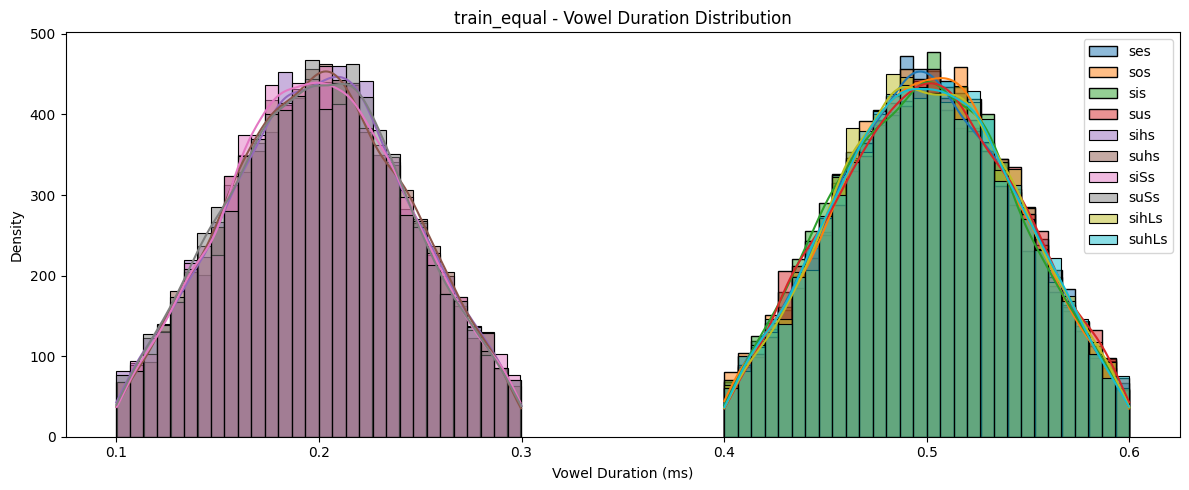

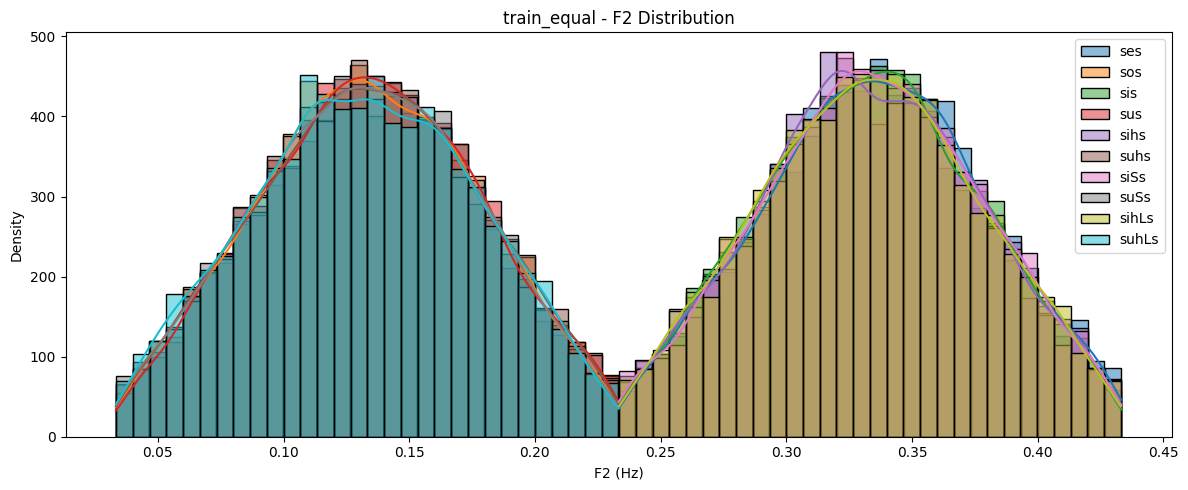

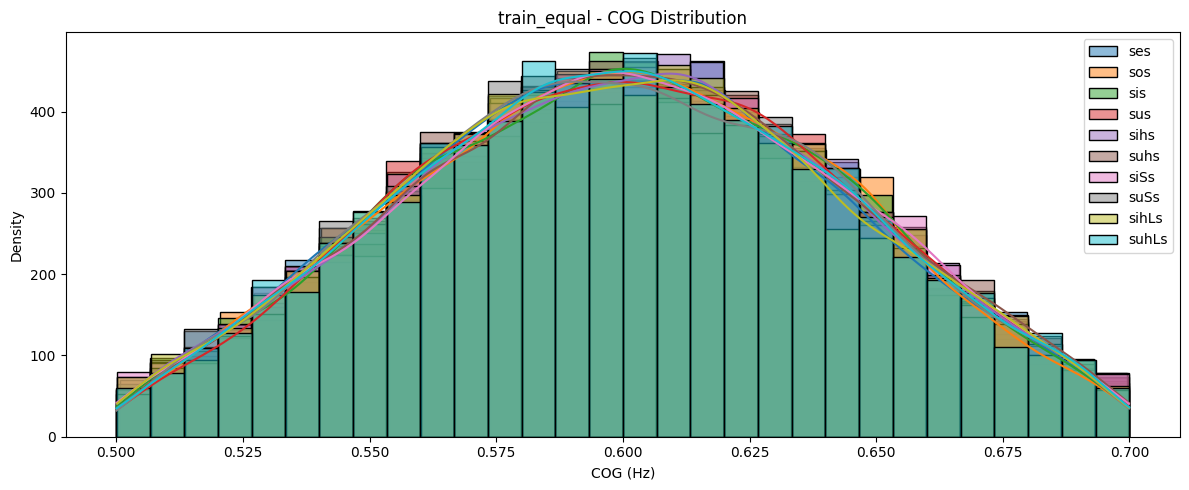

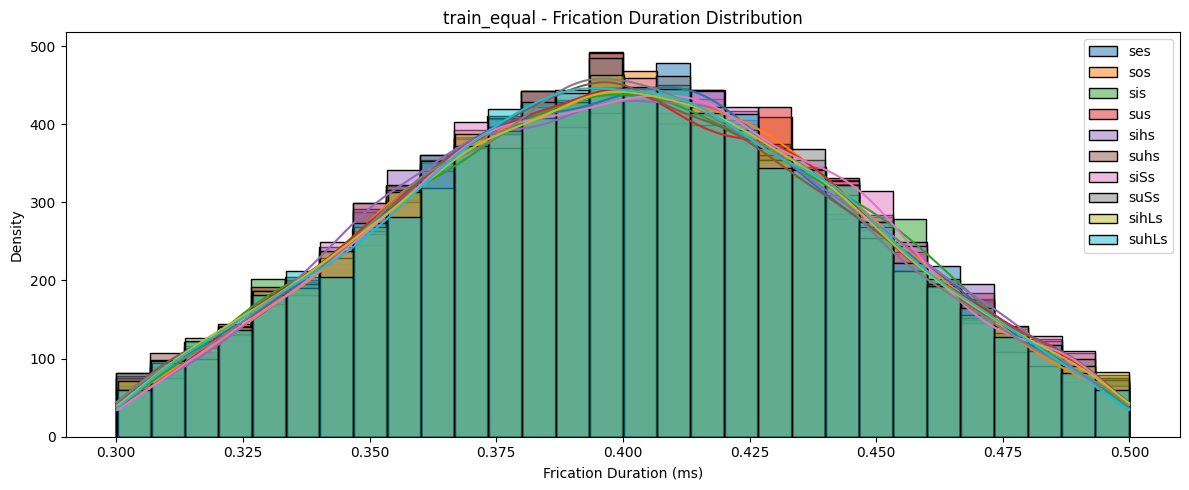

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# plot the distribution of cog and fri_dur for all four words (words together, plot separate by dimension like cog or fri_dur)
plt.figure(figsize=(12, 5))
for word in token_dict:
    # bar plot and kde plot together
    sns.histplot(token_dict[word][:, 1, 0], bins=30, kde=True, label=word)  # cog is the first dimension of the consonant part
    # sns.kdeplot(token_dict[word][:, 1, 0], label=word)  # cog is the first dimension of the consonant part
plt.title(f'{condition} - F1 Distribution')
plt.xlabel('F1 (Hz)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for word in token_dict: 
    sns.histplot(token_dict[word][:, 1, 1], bins=30, kde=True, label=word)  # fri_dur is the second dimension of the consonant part
    # sns.kdeplot(token_dict[word][:, 1, 1], label=word)  # fri_dur is the second dimension of the consonant part
plt.title(f'{condition} - Vowel Duration Distribution')
plt.xlabel('Vowel Duration (ms)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for word in token_dict:
    # bar plot and kde plot together
    sns.histplot(token_dict[word][:, 1, 2], bins=30, kde=True, label=word)  # cog is the first dimension of the consonant part
    # sns.kdeplot(token_dict[word][:, 1, 2], label=word)  # cog is the first dimension of the consonant part
plt.title(f'{condition} - F2 Distribution')
plt.xlabel('F2 (Hz)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for word in token_dict: 
    sns.histplot(token_dict[word][:, 0, 3], bins=30, kde=True, label=word)  # fri_dur is the second dimension of the consonant part
    # sns.kdeplot(token_dict[word][:, 1, 3], label=word)  # fri_dur is the second dimension of the consonant part
plt.title(f'{condition} - COG Distribution')
plt.xlabel('COG (Hz)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for word in token_dict: 
    sns.histplot(token_dict[word][:, 0, 4], bins=30, kde=True, label=word)  # fri_dur is the second dimension of the consonant part
    # sns.kdeplot(token_dict[word][:, 2, 4], label=word)  # fri_dur is the second dimension of the consonant part
plt.title(f'{condition} - Frication Duration Distribution')
plt.xlabel('Frication Duration (ms)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# Some Quick Notes

Becuase I am generating data here. I leave some notes here for future refernce: 
1. When generating data, just run through it. Changing vairance is done by changing `CONSONANT_/VOWEL_CONFIGURED_VARIANCE`. Changing mean is done in each condition separately. 
2. After generating the data, they will appear in the hyperdir of this dir. Need to put them all into a dir for transfering. 
3. Use `scp -r /mnt/data/Projects/XXX franklhtan@10.64.109.137:/nfs/franklhtan/projects/LearnCsld2025/` to transfer. XXX is the data collection name. This should be the same as configured in `write_dir = "/mnt/storage/ldl_linguistics/PhonGen2025_diag_new/XXX/"`. NB. transmission of many small files may be slow, we can compress into .zip file first and then use `scp -r /mnt/data/Projects/XXX.zip franklhtan@10.64.109.137:/nfs/franklhtan/projects/LearnCsld2025/` to transmit, and then use `unzip XXX.zip` on the server to unzip. This saves more than 10 minutes on large collections of small files like this. 

## How to transfer
1. Zip (do this on local computer): `tar -czvf /mnt/data/Projects/XXX.tar.gz /mnt/data/Projects/XXX`
2. Transfer: `scp -r /mnt/data/Projects/XXX.tar.gz franklhtan@10.64.109.137:/nfs/franklhtan/projects/LearnCsld2025/`
3. Unzip (do this on server): `tar -xzvf XXX.tar.gz`